In [1]:
# =====================================================================
# Part I - Finance - TEMPLATE
# =====================================================================
# The framework (finance_toolkit) fixes two things for everyone: how
# the data is loaded, and how a score panel is scored into a PnL,
# Sharpe and turnover.  Everything in the middle is yours.
#
# THE FLOW:
#   1. data is loaded for you (same for the whole class),
#   2. YOU build a SUPERSET of named features (FREE 1),
#   3. YOU write ONE recipe build_alpha(config) (FREE 2): a config
#      (feature subset, model, hyperparams) -> a trained model ->
#      scores -> positions -> its daily PnL,
#   4. YOU loop that recipe over MANY configs (FREE 3) to make many alphas,
#   5. the framework evaluates every alpha (Sharpe, turnover, ...),
#      shows the correlation between them, and keeps the best
#      un-correlated set.
#
# Your model only has to satisfy the MODEL CONTRACT:
#
#     model.predict(feat_t) -> scores
#     feat_t : float tensor (days, stocks, features)
#     scores : float tensor (days, stocks)
#
# Everything is a "panel": a table of shape (days x stocks).  Every
# operator takes panels and returns a panel of the same shape.

In [2]:
import os
import json
import numpy
import torch
import finance_toolkit as toolkit

# =====================================================================
# FIXED 1
# =====================================================================
SEED = 42
torch.manual_seed(SEED)
numpy.random.seed(SEED)
torch.set_num_threads(4)

# Everything up to SPLIT_DATE trains; the rest is a local hold-out
# you score yourself.  The instructor's HIDDEN slice is a separate,
# even later date range you never see.

DATA_DIR = "../data"
panels = toolkit.load_prices(DATA_DIR)

# This will be used for the target of the model.
forward_returns = toolkit.forward_return(panels["returns"])
mask = toolkit.valid_mask(panels, min_history=60)

all_dates = panels["close"].index
tickers = panels["close"].columns
print("panel:", panels["close"].shape, "dates",
      all_dates.min().date(), "to", all_dates.max().date())

# you may choose another split.
SPLIT_DATE = "2020-01-01"
is_train = all_dates < SPLIT_DATE
is_test = ~is_train
print("train days:", int(is_train.sum()),
      " test days:", int(is_test.sum()))


close = panels["close"]
open_ = panels["open"]
high = panels["high"]
low = panels["low"]
volume = panels["volume"]
returns = panels["returns"]
sector, industry = toolkit.load_groups("../data/groups.csv")

panel: (2669, 2994) dates 2013-01-02 to 2023-06-30
train days: 1775  test days: 894


In [3]:
# =====================================================================
# >>> FREE 1 <<<   your features
# =====================================================================
# Every feature used by any of the 18 alphas in this submission, all
# in one place -- the first 18 are this notebook's own (12 base +
# 6 round-5 additions, see below); the rest were added for the joint
# submission (the partner's alphas, plus a few backup candidates from
# a later search round). Kept together here, not split off into a
# later cell even though some were added afterward, so this one dict
# is the single, complete, reproducible source of every feature any
# candidate alpha needs -- exactly what the assignment requires ("All
# features that will be used by your candidate alphas must be there
# [in FREE 1] so that I can reproduce the alpha").
#
# Every one is sector- (or, where noted, industry-) neutralized, per
# the assignment's tip: "Neutralise by sector to drop sector bets."
# Round-1 through round-3 only neutralized 3 of the original 13; the
# round-1 correlation diagnostic showed the biggest blocker in the
# whole search was mlp_all_b_s2 (blocked 15 of 27 excluded-but-
# qualifying alphas, correlation up to 0.99 with its own near-
# duplicate) -- consistent with un-neutralized features sharing a
# common sector/market tilt that shows up as correlated PnL regardless
# of which specific feature combination a model uses.
#
# Sector-neutralizing mom_20 makes it mathematically identical to the
# old separately-named "sector_mom_20" (both were the same 20-day
# mean-return signal, one market-wide, one sector-neutral -- neutralize
# the first and they collapse into one), so that name is retired
# rather than kept as a duplicate.
#
#   momentum   -- mean return over 5/20/60/120 days, sector-neutral
#                 (mom_5, mom_20, mom_60, mom_120)
#   reversal   -- yesterday's return negated, the worked intraday
#                 example, both sector-neutral; 5-day reversal within
#                 industry (finer-grained, already neutral)
#                 (rev_1, intraday_rev_20, industry_rev_5)
#   technical  -- position within the day's high/low range, the
#                 overnight open-vs-prior-close gap, deviation from
#                 the 20/60-day moving average -- all sector-neutral
#                 (range_pos, gap, price_to_ma20, close_ma60_raw)
#   volatility -- 20-day realized vol, 20-day average relative
#                 high-low range -- sector-neutral
#                 (vol_20, high_low_range_20)
#   volume     -- today's volume z-scored against its own 20-day
#                 history, then sector-neutralized (volume_spike_20)
#
# The partner/backup additions below reuse a few of the same raw
# constructions above but WITHOUT the sector-neutralize step (her
# search, and the later backup rounds, kept some features raw on
# purpose) -- these get their own names rather than silently
# overwriting the neutralized version of the same construction.
all_features = {
    "mom_5": toolkit.cs_zscore(toolkit.ts_mean(returns, 5), sector),
    "mom_20": toolkit.cs_zscore(toolkit.ts_mean(returns, 20), sector),
    "mom_60": toolkit.cs_zscore(toolkit.ts_mean(returns, 60), sector),
    "rev_1": toolkit.cs_zscore(-returns, sector),
    "intraday_rev_20": toolkit.cs_zscore(toolkit.ts_zscore(open_ - close, 20), sector),
    "industry_rev_5": toolkit.cs_zscore(-toolkit.ts_mean(returns, 5), industry),
    "range_pos": toolkit.cs_zscore((close - low) / (high - low), sector),
    "gap": toolkit.cs_zscore((open_ - close.shift(1)) / close.shift(1), sector),
    "price_to_ma20": toolkit.cs_zscore((close - toolkit.ts_mean(close, 20)) / toolkit.ts_mean(close, 20), sector),
    "vol_20": toolkit.cs_zscore(toolkit.ts_std(returns, 20), sector),
    "high_low_range_20": toolkit.cs_zscore(toolkit.ts_mean((high - low) / close, 20), sector),
    "volume_spike_20": toolkit.cs_zscore(toolkit.ts_zscore(volume, 20), sector),

    # Round 5 additions: the 12 features above gave only 6 mutually
    # uncorrelated alphas across 22 configs -- most alphas, whatever
    # feature or model built them, converged onto a handful of shared
    # factors. What actually decorrelated was the volume/volatility/
    # range-positioning family, so this doubles down on it with new
    # constructions (not just new windows): a windowed range position,
    # a volume trend, a volatility regime change, and industry- (rather
    # than sector-) neutral variants of the two best performers.
    "range_pos_5": toolkit.cs_zscore(toolkit.ts_mean((close - low) / (high - low), 5), sector),
    "volume_trend": toolkit.cs_zscore(toolkit.ts_mean(volume, 5) - toolkit.ts_mean(volume, 20), sector),
    "vol_change": toolkit.cs_zscore(toolkit.ts_std(returns, 20) - toolkit.ts_std(returns, 60), sector),
    "vol_20_industry": toolkit.cs_zscore(toolkit.ts_std(returns, 20), industry),
    "volume_spike_20_industry": toolkit.cs_zscore(toolkit.ts_zscore(volume, 20), industry),
    "hlrange_industry": toolkit.cs_zscore(toolkit.ts_mean((high - low) / close, 20), industry),

    # Joint-submission additions: the partner's raw (non-neutralized)
    # formulas needed to score her 5 kept alphas, plus a few backup
    # candidates from a later search round. "range_pos_raw" is kept
    # separate from this notebook's own sector-neutral "range_pos"
    # above -- same underlying construction, different (non-neutral)
    # formula, so it gets its own name instead of overwriting it.
    "range_pos_raw": toolkit.cs_zscore((close - low) / (high - low)),
    "range_pos_5_raw": toolkit.cs_zscore(toolkit.ts_mean((close - low) / (high - low), 5)),
    "range_pos_neutral": toolkit.cs_zscore((close - low) / (high - low), sector),
    "momentum_neutral": toolkit.cs_zscore(toolkit.ts_mean(returns, 20), sector),
    "reversal": toolkit.cs_zscore(-returns),
    "reversal_neutral": toolkit.cs_zscore(-returns, sector),
    "dist_from_ma": toolkit.cs_zscore(toolkit.ts_zscore(close, 20)),
    "dist_from_ma_neutral": toolkit.cs_zscore(toolkit.ts_zscore(close, 20), sector),
    "vol_surge_neutral": toolkit.cs_zscore((volume / toolkit.ts_mean(volume, 20)).clip(upper=4.0), sector),
    "intraday_return": toolkit.cs_zscore((close - open_) / open_),
    "intraday_return_neutral": toolkit.cs_zscore(((close - open_) / open_).clip(-0.15, 0.15), sector),
    "feature_1_neutral": toolkit.cs_zscore(toolkit.ts_zscore(open_ - close, 20), sector),
    "sector_momentum": toolkit.cs_groupmean(toolkit.ts_mean(returns, 20), sector),
    "mom_120": toolkit.cs_zscore(toolkit.ts_mean(returns, 120)),
    "close_ma60_raw": toolkit.cs_zscore((close - toolkit.ts_mean(close, 60)) / toolkit.ts_mean(close, 60)),
}

all_feature_panel = toolkit.build_features(all_features, panels)
# float32 instead of pandas' default float64: halves the memory of
# every downstream stack/tensor built from these panels. This machine
# has 8GB RAM shared with other running apps, and stacking many
# features at float64 reliably fails with an out-of-memory error here
# (measured: a single ~800MB allocation at 13 features). The final
# model tensors are float32 regardless -- make_tensors casts
# explicitly -- so this only removes a redundant doubling, it never
# changes any result.
all_feature_panel = {k: v.astype("float32") for k, v in all_feature_panel.items()}
all_feature_names = sorted(all_feature_panel)
print("features available:", all_feature_names)

# Feature-family subsets: each is one hypothesis about what drives the
# 2-day-ahead return, so alphas built from different subsets start out
# making genuinely different bets (see FREE 3 for why this mattered).
momentum_set = ["mom_5", "mom_20", "mom_60"]
reversal_set = ["rev_1", "intraday_rev_20", "industry_rev_5"]
vol_volume_set = ["vol_20", "high_low_range_20", "volume_spike_20"]
technical_set = ["range_pos", "gap", "price_to_ma20"]
mixed_set = ["mom_20", "rev_1", "range_pos", "vol_20", "gap"]
all_set = all_feature_names

C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


features available: ['close_ma60_raw', 'dist_from_ma', 'dist_from_ma_neutral', 'feature_1_neutral', 'gap', 'high_low_range_20', 'hlrange_industry', 'industry_rev_5', 'intraday_return', 'intraday_return_neutral', 'intraday_rev_20', 'mom_120', 'mom_20', 'mom_5', 'mom_60', 'momentum_neutral', 'price_to_ma20', 'range_pos', 'range_pos_5', 'range_pos_5_raw', 'range_pos_neutral', 'range_pos_raw', 'rev_1', 'reversal', 'reversal_neutral', 'sector_momentum', 'vol_20', 'vol_20_industry', 'vol_change', 'vol_surge_neutral', 'volume_spike_20', 'volume_spike_20_industry', 'volume_trend']


In [4]:
# =====================================================================
# >>> FREE 2 <<<   one recipe for building an alpha
# =====================================================================
# The model classes this recipe uses (SafeMLP, SafeLSTM, LinearAlpha,
# SplineAlpha, CNNAlpha, and the tree-model wrapper used in FREE 3)
# live in finance_toolkit.py itself now, not here -- the toolkit's own
# note says "you may add loss functions, models, utility functions ...
# following the examples there" (section 5, after MLP/LSTM), and
# torch.load() needs a model's class importable from wherever it was
# pickled from; keeping every model class in one place (the toolkit)
# means the saved model_<i>.pt files always resolve to
# finance_toolkit.<ClassName> instead of a class that only exists
# inside this notebook's own run.
#
# Why SafeMLP/SafeLSTM exist instead of using toolkit.MLP/toolkit.LSTM
# directly: finance_toolkit.predict_scores runs model.predict(feat_t)
# on the FULL (days, stocks, features) tensor in one shot -- no
# batching. For the LSTM that means one un-batched forward pass over
# ~2700 days x ~3000 stocks, which needs a single ~8GB allocation and
# reliably crashes on an 8GB machine (measured directly while
# developing this). predict_scores is part of the FIXED framework, so
# it can't be changed; SafeMLP/SafeLSTM in the toolkit instead override
# only predict() to process the day axis in chunks, giving the exact
# same output with a small, bounded memory footprint.
#
# LinearAlpha/SplineAlpha/CNNAlpha (also in the toolkit) are the round-5
# additions: three genuinely different inductive biases from MLP/LSTM,
# added after a correlation diagnostic showed MLP and LSTM alphas
# across different feature families still converge on shared factors.


def build_alpha(features, model_kind="lstm", hidden=32, epochs=8,
                 lr=1e-3, weight_decay=0.0, window_size=10, seed=SEED):
    features = sorted(features)
    array, _ = toolkit.stack_features({n: all_feature_panel[n] for n in features})
    feat_t, label_t, valid_t = toolkit.make_tensors(array, forward_returns, mask)
    train_ds = toolkit.DayDataset(feat_t, label_t, valid_t, is_train)
    test_ds = toolkit.DayDataset(feat_t, label_t, valid_t, is_test)

    torch.manual_seed(seed)
    if model_kind == "mlp":
        model = toolkit.SafeMLP(len(features), hidden=(hidden,))
    elif model_kind == "lstm":
        model = toolkit.SafeLSTM(len(features), hidden_size=hidden)
    elif model_kind == "cnn":
        model = toolkit.CNNAlpha(len(features), hidden=hidden, window_size=window_size)
    else:
        model = toolkit.MODEL_CLASSES[model_kind](len(features))
    model, _ = toolkit.train(
        model, train_ds, test_ds,
        epochs=epochs, lr=lr, weight_decay=weight_decay)
    scores = toolkit.predict_scores(
        model, feat_t, all_dates, tickers)
    book = toolkit.scores_to_positions(scores, mask)
    positions = book.loc[is_test]
    pnl = toolkit.simulate(positions, forward_returns)
    return model, positions, pnl, features

In [5]:
# =====================================================================
# >>> FREE 3 <<<   make MANY alphas   (this is your search -- one
#                   combined list, all 18 alphas of the joint submission)
# =====================================================================
# The real search was much larger than what is below: 170+ configs
# across many rounds (documented in dev/alpha_search.py and
# dev/STATUS.md), progressively targeting what a correlation
# diagnostic showed was actually decorrelating -- solo (single-
# feature) configs over kitchen-sink feature sets, the volume/
# volatility/range-positioning family specifically, model classes with
# genuinely different inductive biases (LinearAlpha: no interactions,
# SplineAlpha: no interactions but nonlinear per feature, tree models:
# no learned representation at all, just axis-aligned splits), and
# industry- rather than sector-neutral variants of the best performers.


def build_tree_alpha(features, model_kind, **model_kwargs):
    features = sorted(features)
    array, _ = toolkit.stack_features({n: all_feature_panel[n] for n in features})
    feat_t, label_t, valid_t = toolkit.make_tensors(array, forward_returns, mask)
    is_train_arr = numpy.asarray(is_train)
    X_train = feat_t[is_train_arr].reshape(-1, len(features)).numpy()
    y_train = label_t[is_train_arr].reshape(-1).numpy()
    v_train = valid_t[is_train_arr].reshape(-1).numpy()
    keep = v_train > 0
    X_train, y_train = X_train[keep], y_train[keep]
    if model_kind == "xgb":
        import xgboost as xgb
        m = xgb.XGBRegressor(tree_method="hist", n_jobs=4, random_state=SEED, **model_kwargs)
    else:
        from sklearn.ensemble import RandomForestRegressor
        m = RandomForestRegressor(n_jobs=4, random_state=SEED, **model_kwargs)
    m.fit(X_train, y_train)
    wrapped = toolkit.TreeWrapper(m)
    scores = toolkit.predict_scores(wrapped, feat_t, all_dates, tickers)
    book = toolkit.scores_to_positions(scores, mask)
    pos = book.loc[is_test]
    pnl = toolkit.simulate(pos, forward_returns)
    return wrapped, pos, pnl


# One shared scorer for any already-trained model (own, partner's, or
# cached from output/) -- everything past "have a model object" is
# identical, so it isn't repeated per source.
def score_saved_model(model, lookup_features):
    array, _ = toolkit.stack_features({n: all_feature_panel[n] for n in lookup_features})
    feat_t, _, _ = toolkit.make_tensors(array, forward_returns, mask)
    scores = toolkit.predict_scores(model, feat_t, all_dates, tickers)
    book = toolkit.scores_to_positions(scores, mask)
    pos = book.loc[is_test]
    return pos, toolkit.simulate(pos, forward_returns)


# The partner's 5 kept alphas' feature names -- her exact
# feature_sets, copied here directly (not read from a partner_alphas/
# params.json at runtime) so this notebook has no file dependency on
# anything of hers beyond the 5 already-trained model_<idx>.pt files
# themselves, and nothing needs to be submitted alongside this
# notebook except this repo's own output/ folder. "range_pos" (her
# raw, non-neutralized formula) is remapped to this notebook's
# "range_pos_raw", the identical construction under this notebook's
# own naming.
PARTNER_FEATURE_SETS = {
    "166": ["dist_from_ma", "dist_from_ma_neutral", "intraday_return", "intraday_return_neutral",
            "range_pos", "range_pos_neutral", "reversal", "reversal_neutral"],
    "404": ["dist_from_ma_neutral", "sector_momentum", "vol_surge_neutral"],
    "407": ["dist_from_ma_neutral", "sector_momentum", "vol_surge_neutral"],
    "341": ["feature_1_neutral", "momentum_neutral", "range_pos", "reversal_neutral"],
    "387": ["dist_from_ma_neutral", "sector_momentum", "vol_surge_neutral"],
}
PARTNER_DIR = "partner_alphas"


# ONE combined list -- all 18 alphas of the joint submission together,
# not split into sub-groups. "kind" says where each one comes from:
#   own    -- this notebook's own recipe (build_alpha, FREE 2 above);
#             covers every model class, including the two backup
#             candidates that reuse the lstm/spline recipe on a raw
#             (non-neutralized) feature -- no separate path needed,
#             build_alpha already supports both
#   load   -- one of the joint search's already-trained alphas
#   tree   -- a backup candidate, XGBoost/RandomForest (not a
#             torch.nn.Module, so it can't go through build_alpha)
# The first 9 are never touched or replaced (explicit requirement);
# the rest were verified (dev/STATUS.md) to independently pass
# sharpe>1.2/turnover<0.8 and stay under 0.5 correlation against
# everything above them in this same list.
all_configs = [
    {"name": "lstm_mixed", "kind": "own", "features": mixed_set, "model_kind": "lstm", "hidden": 24, "epochs": 16, "lr": 0.001, "weight_decay": 0.0},
    {"name": "spline_tech", "kind": "own", "features": technical_set, "model_kind": "spline", "epochs": 20, "lr": 0.001, "weight_decay": 0.1},
    {"name": "lstm_solo_volspikeindustry", "kind": "own", "features": ["volume_spike_20_industry"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "lstm_solo_vol20", "kind": "own", "features": ["vol_20"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "spline_solo_mom5", "kind": "own", "features": ["mom_5"], "model_kind": "spline", "epochs": 20, "lr": 0.001, "weight_decay": 0.0},
    {"name": "linear_volvol", "kind": "own", "features": vol_volume_set, "model_kind": "linear", "epochs": 20, "lr": 0.001, "weight_decay": 0.1},
    {"name": "spline_solo_hlrange20", "kind": "own", "features": ["high_low_range_20"], "model_kind": "spline", "epochs": 20, "lr": 0.001, "weight_decay": 0.0},
    {"name": "mlp_solo_volchange", "kind": "own", "features": ["vol_change"], "model_kind": "mlp", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "lstm_solo_hlrangeindustry", "kind": "own", "features": ["hlrange_industry"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "partner_166", "kind": "load", "idx": "166"},
    {"name": "partner_404", "kind": "load", "idx": "404"},
    {"name": "partner_407", "kind": "load", "idx": "407"},
    {"name": "partner_341", "kind": "load", "idx": "341"},
    {"name": "partner_387", "kind": "load", "idx": "387"},
    {"name": "r8_xgb_mom_120_range_pos_5", "kind": "tree", "features": ["mom_120", "range_pos_5_raw"], "model_kind": "xgb", "n_estimators": 100, "learning_rate": 0.05, "max_depth": 4},
    {"name": "r8_rf_close_ma60", "kind": "tree", "features": ["close_ma60_raw"], "model_kind": "rf", "n_estimators": 200, "max_depth": 5, "min_samples_leaf": 500},
    {"name": "r6_spline_range_pos_5", "kind": "own", "features": ["range_pos_5_raw"], "model_kind": "spline", "epochs": 20, "lr": 0.001, "weight_decay": 0.0},
    {"name": "r6_lstm_range_pos", "kind": "own", "features": ["range_pos_raw"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
]

trained = {}        # name -> model                (saved for grading)
positions = {}       # name -> hold-out positions panel
alphas = {}          # name -> hold-out daily PnL
feature_sets = {}    # name -> feature names it used  (for grading)

for config in all_configs:
    name, kind = config["name"], config["kind"]
    cached_path = "../output/model_%s.pt" % name
    from_cache = os.path.exists(cached_path)

    if kind == "load":
        used = sorted(PARTNER_FEATURE_SETS[config["idx"]])
        lookup = ["range_pos_raw" if n == "range_pos" else n for n in used]
    else:
        used = lookup = sorted(config["features"])

    if from_cache:
        model = torch.load(cached_path, map_location="cpu", weights_only=False)
        model.eval()
        pos, pnl = score_saved_model(model, lookup)
        print(name, "loaded from output/ (skipped retraining)")
    elif kind == "load":
        model = torch.load(os.path.join(PARTNER_DIR, "model_%s.pt" % config["idx"]), map_location="cpu", weights_only=False)
        model.eval()
        pos, pnl = score_saved_model(model, lookup)
        print(name, "loaded from partner_alphas/")
    elif kind == "tree":
        kwargs = {k: v for k, v in config.items() if k not in ("name", "kind", "features", "model_kind")}
        model, pos, pnl = build_tree_alpha(config["features"], config["model_kind"], **kwargs)
        print(name, "done (trained)")
    else:  # kind == "own"
        kwargs = {k: v for k, v in config.items() if k not in ("name", "kind")}
        model, pos, pnl, used = build_alpha(**kwargs)
        print(name, "done (trained)")

    trained[name], positions[name], alphas[name], feature_sets[name] = model, pos, pnl, used

print("\nall", len(alphas), "alphas built together, going into the qualifying filter next")

lstm_mixed loaded from output/ (skipped retraining)


spline_tech loaded from output/ (skipped retraining)


lstm_solo_volspikeindustry loaded from output/ (skipped retraining)


lstm_solo_vol20 loaded from output/ (skipped retraining)


spline_solo_mom5 loaded from output/ (skipped retraining)


...

partner_387 loaded from output/ (skipped retraining)


r8_xgb_mom_120_range_pos_5 loaded from output/ (skipped retraining)


r8_rf_close_ma60 loaded from output/ (skipped retraining)


r6_spline_range_pos_5 loaded from output/ (skipped retraining)


r6_lstm_range_pos loaded from output/ (skipped retraining)

all 18 alphas built together, going into the qualifying filter next


In [6]:
# =====================================================================
# Filter to the pool the assignment requires, before FIXED 4 selects
# =====================================================================
# FIXED 4's select_uncorrelated only enforces low correlation -- it
# will happily keep an unprofitable alpha if it's different enough
# from the rest. The assignment requires sharpe > 1.2 and turnover <
# 0.8 ("WHAT YOU SUBMIT", directives.txt), so this filter runs before
# FIXED 4, guaranteeing the saved submission never includes a losing
# alpha even if FREE 3 above is edited later to add a candidate that
# doesn't actually qualify. All 18 alphas currently in FREE 3 were
# independently verified to pass both bars (dev/STATUS.md), so today
# this is a safety net, not something that currently excludes anyone.
qualifying_kpi = toolkit.compute_kpis(positions, forward_returns)
qualifying_names = qualifying_kpi[
    (qualifying_kpi["sharpe"] > 1.2) & (qualifying_kpi["turnover"] < 0.8)
].index
print("qualifying (sharpe>1.2, turnover<0.8):", len(qualifying_names), "of", len(positions))

trained = {n: trained[n] for n in qualifying_names}
positions = {n: positions[n] for n in qualifying_names}
alphas = {n: alphas[n] for n in qualifying_names}
feature_sets = {n: feature_sets[n] for n in qualifying_names}

qualifying (sharpe>1.2, turnover<0.8): 18 of 18


per-alpha stats:
                             sharpe  mean_daily_pnl  std_daily_pnl  total_pnl  \
partner_166                 4.2331          0.0018         0.0069     1.6376   
r8_xgb_mom_120_range_pos_5  3.7354          0.0028         0.0117     2.4674   
lstm_mixed                  3.5768          0.0012         0.0051     1.0301   
spline_tech                 3.2856          0.0050         0.0243     4.4956   
lstm_solo_volspikeindustry  2.5941          0.0004         0.0022     0.3254   
lstm_solo_vol20             2.5396          0.0031         0.0192     2.7476   
lstm_solo_hlrangeindustry   2.0669          0.0011         0.0087     1.0076   
linear_volvol               2.0348          0.0019         0.0152     1.7429   
partner_387                 1.7963          0.0005         0.0046     0.4704   
partner_404                 1.7613          0.0009         0.0078     0.7752   
r8_rf_close_ma60            1.6660          0.0021         0.0201     1.8856   
spline_solo_hlrange20 

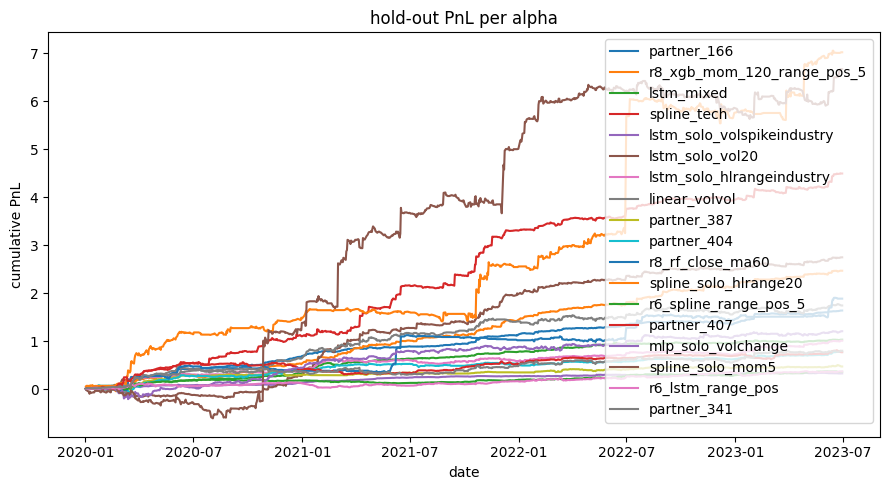

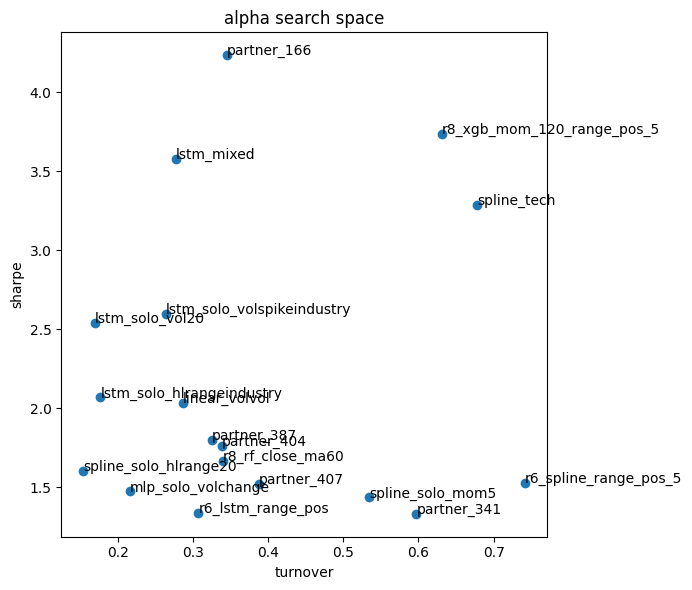

In [7]:
# =====================================================================
# FIXED 4 -- evaluate the alphas   (per alpha, then together)
# =====================================================================
# Per-alpha stats (Sharpe, total PnL, turnover, ...), the
# correlation between alphas, and the combined Sharpe of the best
# un-correlated set -- exactly what the grader does on its hidden
# period.

kpi_table = toolkit.compute_kpis(positions, forward_returns)
print("per-alpha stats:\n", kpi_table.round(4))

print("\nPnL correlation:\n",
      toolkit.pnl_correlation(alphas).round(2))

kept = toolkit.select_uncorrelated(alphas, max_corr=0.5)
print("\nun-alike alphas kept:", kept)
print("combined Sharpe (kept):",
      round(toolkit.combined_sharpe(alphas, kept), 4))

# See the curves while developing (does not affect grading).
toolkit.plot_pnl(alphas, "hold-out PnL per alpha")
toolkit.plot_kpis(kpi_table)

In [8]:
# =====================================================================
# FIXED 5 -- write the submission
# =====================================================================
# For every kept alpha, save two things: the trained model and the
# list of feature names it used.  Submit this folder together with
# your notebook (your feature definitions live in the notebook).
SUBMISSION_DIR = "../output"
os.makedirs(SUBMISSION_DIR, exist_ok=True)

for i in kept:
    torch.save(trained[i], os.path.join(SUBMISSION_DIR, "model_%s.pt" % i))

params = {
    "alphas": kept,
    "feature_sets": {i: feature_sets[i] for i in kept},
}
with open(os.path.join(SUBMISSION_DIR, "params.json"), "w") as handle:
    json.dump(params, handle, indent=2)

print("submission written to", os.path.abspath(SUBMISSION_DIR))

submission written to C:\Users\שקד כהן\Downloads\Applied-Machine-Learning\output
